In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime > Change runtime type > GPU.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: NVIDIA L4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/cs4782_persam_project"
os.makedirs(PROJECT_ROOT, exist_ok=True)

print("Project folder:", PROJECT_ROOT)

Project folder: /content/drive/MyDrive/cs4782_persam_project


In [5]:
%cd /content/drive/MyDrive/cs4782_persam_project

!git clone https://github.com/ZrrSkywalker/Personalize-SAM.git

/content/drive/MyDrive/cs4782_persam_project
fatal: destination path 'Personalize-SAM' already exists and is not an empty directory.


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
!ls

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
app.py	       figs		      persam_video_f.py     requirements.txt
davis2017      LICENSE.txt	      persam_video.py	    show.py
eval_miou.py   persam_f_multi_obj.py  per_segment_anything  weights
eval_video.py  persam_f.py	      prepare_coco.py
examples       persam.py	      README.md


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!pip install -r requirements.txt
!pip install git+https://github.com/facebookresearch/segment-anything.git

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-wbglc9jw
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-wbglc9jw
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=df442ee28d5c59d99574807decbf803d28a62cbb72d73ee19ab9b5206f8c5bcf
  Stored in directory: /tmp/pip-ephem-wheel-cache-0k471m01/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!pip install matplotlib tqdm numpy opencv-python
!pip install git+https://github.com/facebookresearch/segment-anything.git

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-dr73qbi3
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-dr73qbi3
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import argparse
import warnings

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from segment_anything import sam_model_registry, SamPredictor

print("All imports successful!")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

All imports successful!
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!wget -nc https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
!ls -lh sam_vit_h_4b8939.pth

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
File ‘sam_vit_h_4b8939.pth’ already there; not retrieving.

-rw------- 1 root root 2.4G Apr  4  2023 sam_vit_h_4b8939.pth


In [ ]:
!ls -lh sam_vit_h_4b8939.pth

-rw------- 1 root root 2.4G Apr  4  2023 sam_vit_h_4b8939.pth


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!unzip -q ../PerSeg.zip -d .

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM


In [ ]:
!find data -maxdepth 2 -type d | head
!ls data

find: ‘data’: No such file or directory
ls: cannot access 'data': No such file or directory


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

print("Current folder:")
!pwd

print("\nFiles/folders in current folder:")
!ls -lah

print("\nFiles/folders in parent folder:")
!ls -lah ..

print("\nAll folders under current folder, depth <= 3:")
!find . -maxdepth 3 -type d | sort | head -100

print("\nCheck zip content:")
!unzip -l ../PerSeg.zip | head -50

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Current folder:
/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

Files/folders in current folder:
total 2.4G
-rw------- 1 root root  21K May  1 22:37  app.py
drwx------ 4 root root 4.0K May  1 22:49 'data 3'
drwx------ 2 root root 4.0K May  1 22:37  davis2017
-rw------- 1 root root 3.1K May  1 22:37  eval_miou.py
-rw------- 1 root root 3.4K May  1 22:37  eval_video.py
drwx------ 2 root root 4.0K May  1 22:37  examples
drwx------ 2 root root 4.0K May  1 22:37  figs
drwx------ 8 root root 4.0K May  1 22:37  .git
-rw------- 1 root root  350 May  1 22:37  .gitignore
-rw------- 1 root root 1.1K May  1 22:37  LICENSE.txt
drwx------ 3 root root 4.0K May  1 22:49  __MACOSX
-rw------- 1 root root  14K May  1 22:37  persam_f_multi_obj.py
-rw------- 1 root root  12K May  1 22:37  persam_f.py
-rw------- 1 root root 7.1K May  1 22:37  persam.py
-rw------- 1 root root  16K May  1 22:37  persam_video_f.py
-rw------- 1 root root

In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!mv "data 3" data
!rm -rf __MACOSX

!ls

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
app.py	       LICENSE.txt	      prepare_coco.py
data	       persam_f_multi_obj.py  README.md
davis2017      persam_f.py	      requirements.txt
eval_miou.py   persam.py	      sam_vit_h_4b8939.pth
eval_video.py  persam_video_f.py      show.py
examples       persam_video.py	      weights
figs	       per_segment_anything


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

print("data folder:")
!ls data

print("\nImage categories:")
!ls data/Images | head

print("\nAnnotation categories:")
!ls data/Annotations | head

print("\nNumber of image categories:")
!find data/Images -mindepth 1 -maxdepth 1 -type d | wc -l

print("\nNumber of annotation categories:")
!find data/Annotations -mindepth 1 -maxdepth 1 -type d | wc -l

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
data folder:
Annotations  Images

Image categories:
backpack
backpack_dog
barn
bear_plushie
berry_bowl
can
candle
cat
cat2
cat_statue

Annotation categories:
backpack
backpack_dog
barn
bear_plushie
berry_bowl
can
candle
cat
cat2
cat_statue

Number of image categories:
40

Number of annotation categories:
40


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

print("Example image files:")
!find data/Images -type f | head -10

print("\nExample annotation files:")
!find data/Annotations -type f | head -10

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Example image files:
data/Images/dog8/00.jpg
data/Images/dog8/01.jpg
data/Images/dog8/03.jpg
data/Images/dog8/02.jpg
data/Images/dog8/06.jpg
data/Images/dog8/07.jpg
data/Images/dog8/05.jpg
data/Images/dog8/04.jpg
data/Images/cat/00.jpg
data/Images/cat/01.jpg

Example annotation files:
data/Annotations/dog8/00.png
data/Annotations/dog8/01.png
data/Annotations/dog8/03.png
data/Annotations/dog8/02.png
data/Annotations/dog8/06.png
data/Annotations/dog8/07.png
data/Annotations/dog8/05.png
data/Annotations/dog8/04.png
data/Annotations/cat/00.png
data/Annotations/cat/01.png


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamPredictor

print("All imports successful!")
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

All imports successful!
CUDA available: True
GPU: NVIDIA L4


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!python persam.py --outdir persam_repro_vith

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Args: Namespace(data='./data', outdir='persam_repro_vith', ckpt='sam_vit_h_4b8939.pth', ref_idx='00', sam_type='vit_h')

------------> Segment dog8
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 8/8 [00:11<00:00,  1.49s/it]

------------> Segment cat
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:07<00:00,  1.50s/it]

------------> Segment dog6
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:07<00:00,  1.55s/it]

------------> Segment dog7
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:08<00:00,  1.61s/it]

------------> Segment wooden_pot
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 4/4 [00:13<00:00,  3.30s/it]

------------> Segment bear_plushie
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:10<00:00,  2.09s/it]

------------> Segme

In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!ls outputs
!find outputs/persam_repro_vith -maxdepth 3 -type f | head -30

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
persam_repro_vith
outputs/persam_repro_vith/dog8/vis_mask_00.jpg
outputs/persam_repro_vith/dog8/00.png
outputs/persam_repro_vith/dog8/vis_mask_01.jpg
outputs/persam_repro_vith/dog8/01.png
outputs/persam_repro_vith/dog8/vis_mask_02.jpg
outputs/persam_repro_vith/dog8/02.png
outputs/persam_repro_vith/dog8/vis_mask_03.jpg
outputs/persam_repro_vith/dog8/03.png
outputs/persam_repro_vith/dog8/vis_mask_04.jpg
outputs/persam_repro_vith/dog8/04.png
outputs/persam_repro_vith/dog8/vis_mask_05.jpg
outputs/persam_repro_vith/dog8/05.png
outputs/persam_repro_vith/dog8/vis_mask_06.jpg
outputs/persam_repro_vith/dog8/06.png
outputs/persam_repro_vith/dog8/vis_mask_07.jpg
outputs/persam_repro_vith/dog8/07.png
outputs/persam_repro_vith/cat/vis_mask_00.jpg
outputs/persam_repro_vith/cat/00.png
outputs/persam_repro_vith/cat/vis_mask_01.jpg
outputs/persam_repro_vith/cat/01.png
outputs/persam_repro_vith/cat/vis_mask_02.jpg
outputs/persam_repro_vith/cat

In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!python eval_miou.py --pred_path persam_repro_vith

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Args: Namespace(pred_path='persam_repro_vith', gt_path='./data/Annotations', ref_idx='00') 

backpack, IoU: 96.17, Acc: 96.25

backpack_dog, IoU: 95.85, Acc: 95.87

barn, IoU: 96.19, Acc: 96.29

bear_plushie, IoU: 89.28, Acc: 89.29

berry_bowl, IoU: 91.81, Acc: 94.27

can, IoU: 38.91, Acc: 78.36

candle, IoU: 74.16, Acc: 74.18

cat, IoU: 95.54, Acc: 95.90

cat2, IoU: 94.72, Acc: 94.88

cat_statue, IoU: 95.42, Acc: 95.88

chair, IoU: 92.23, Acc: 92.25

clock, IoU: 90.70, Acc: 90.72

colorful_sneaker, IoU: 94.48, Acc: 94.53

colorful_teapot, IoU: 96.27, Acc: 96.48

dog, IoU: 96.79, Acc: 96.85

dog2, IoU: 95.66, Acc: 95.74

dog3, IoU: 88.85, Acc: 94.07

dog4, IoU: 95.22, Acc: 95.47

dog5, IoU: 97.10, Acc: 97.17

dog6, IoU: 94.66, Acc: 94.79

dog7, IoU: 93.69, Acc: 94.06

dog8, IoU: 95.34, Acc: 95.58

duck_toy, IoU: 97.31, Acc: 97.31

elephant, IoU: 96.05, Acc: 96.14

fancy_boot, IoU: 95.87, Acc: 95.96

grey_sloth_plushie, IoU: 9

In [ ]:
from pathlib import Path
import shutil

src_root = Path("/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM/outputs/persam_repro_vith")
dst_root = Path("/content/drive/MyDrive/cs4782_persam_project/final_figures/persam_examples")
dst_root.mkdir(parents=True, exist_ok=True)

count = 0
for p in src_root.rglob("vis_mask_*.jpg"):
    category = p.parent.name
    out_name = f"{category}_{p.name}"
    shutil.copy(p, dst_root / out_name)
    count += 1
    if count >= 30:
        break

print("Copied", count, "visualization images to:")
print(dst_root)

Copied 30 visualization images to:
/content/drive/MyDrive/cs4782_persam_project/final_figures/persam_examples


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!mkdir -p /content/drive/MyDrive/cs4782_persam_project/final_results

!python eval_miou.py --pred_path persam_repro_vith | tee /content/drive/MyDrive/cs4782_persam_project/final_results/persam_repro_vith_eval.txt

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Args: Namespace(pred_path='persam_repro_vith', gt_path='./data/Annotations', ref_idx='00') 

backpack, IoU: 96.17, Acc: 96.25

backpack_dog, IoU: 95.85, Acc: 95.87

barn, IoU: 96.19, Acc: 96.29

bear_plushie, IoU: 89.28, Acc: 89.29

berry_bowl, IoU: 91.81, Acc: 94.27

can, IoU: 38.91, Acc: 78.36

candle, IoU: 74.16, Acc: 74.18

cat, IoU: 95.54, Acc: 95.90

cat2, IoU: 94.72, Acc: 94.88

cat_statue, IoU: 95.42, Acc: 95.88

chair, IoU: 92.23, Acc: 92.25

clock, IoU: 90.70, Acc: 90.72

colorful_sneaker, IoU: 94.48, Acc: 94.53

colorful_teapot, IoU: 96.27, Acc: 96.48

dog, IoU: 96.79, Acc: 96.85

dog2, IoU: 95.66, Acc: 95.74

dog3, IoU: 88.85, Acc: 94.07

dog4, IoU: 95.22, Acc: 95.47

dog5, IoU: 97.10, Acc: 97.17

dog6, IoU: 94.66, Acc: 94.79

dog7, IoU: 93.69, Acc: 94.06

dog8, IoU: 95.34, Acc: 95.58

duck_toy, IoU: 97.31, Acc: 97.31

elephant, IoU: 96.05, Acc: 96.14

fancy_boot, IoU: 95.87, Acc: 95.96

grey_sloth_plushie, IoU: 9

In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!python persam_f.py --outdir persam_f_repro_vith

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Args: Namespace(data='./data', outdir='persam_f_repro_vith', ckpt='./sam_vit_h_4b8939.pth', sam_type='vit_h', lr=0.001, train_epoch=1000, log_epoch=200, ref_idx='00')

------------> Segment dog8
======> Load SAM
======> Obtain Self Location Prior
======> Start Training
Train Epoch: 0 / 1000
LR: 0.001000, Dice_Loss: 0.0272, Focal_Loss: 0.0036
Train Epoch: 200 / 1000
LR: 0.000904, Dice_Loss: 0.0222, Focal_Loss: 0.0040
Train Epoch: 400 / 1000
LR: 0.000653, Dice_Loss: 0.0206, Focal_Loss: 0.0043
Train Epoch: 600 / 1000
LR: 0.000344, Dice_Loss: 0.0200, Focal_Loss: 0.0044
Train Epoch: 800 / 1000
LR: 0.000095, Dice_Loss: 0.0197, Focal_Loss: 0.0045
======> Mask weights:
 [[0.01666492]
 [0.6633272 ]
 [0.32000786]]
======> Start Testing
100% 8/8 [00:11<00:00,  1.43s/it]

------------> Segment cat
======> Load SAM
======> Obtain Self Location Prior
======> Start Training
Train Epoch: 0 / 1000
LR: 0.001000, Dice_Loss: 0.0518, Focal_Loss: 

In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!ls outputs
!find outputs/persam_f_repro_vith -maxdepth 3 -type f | head -30

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
persam_f_repro_vith  persam_repro_vith
outputs/persam_f_repro_vith/dog8/vis_mask_00.jpg
outputs/persam_f_repro_vith/dog8/00.png
outputs/persam_f_repro_vith/dog8/vis_mask_01.jpg
outputs/persam_f_repro_vith/dog8/01.png
outputs/persam_f_repro_vith/dog8/vis_mask_02.jpg
outputs/persam_f_repro_vith/dog8/02.png
outputs/persam_f_repro_vith/dog8/vis_mask_03.jpg
outputs/persam_f_repro_vith/dog8/03.png
outputs/persam_f_repro_vith/dog8/vis_mask_04.jpg
outputs/persam_f_repro_vith/dog8/04.png
outputs/persam_f_repro_vith/dog8/vis_mask_05.jpg
outputs/persam_f_repro_vith/dog8/05.png
outputs/persam_f_repro_vith/dog8/vis_mask_06.jpg
outputs/persam_f_repro_vith/dog8/06.png
outputs/persam_f_repro_vith/dog8/vis_mask_07.jpg
outputs/persam_f_repro_vith/dog8/07.png
outputs/persam_f_repro_vith/cat/vis_mask_00.jpg
outputs/persam_f_repro_vith/cat/00.png
outputs/persam_f_repro_vith/cat/vis_mask_01.jpg
outputs/persam_f_repro_vith/cat/01.png
outputs/persam

In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!python eval_miou.py --pred_path persam_f_repro_vith | tee /content/drive/MyDrive/cs4782_persam_project/final_results/persam_f_repro_vith_eval.txt

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Args: Namespace(pred_path='persam_f_repro_vith', gt_path='./data/Annotations', ref_idx='00') 

backpack, IoU: 96.66, Acc: 96.77

backpack_dog, IoU: 95.76, Acc: 95.80

barn, IoU: 95.17, Acc: 95.26

bear_plushie, IoU: 95.32, Acc: 95.33

berry_bowl, IoU: 91.27, Acc: 93.82

can, IoU: 97.49, Acc: 97.56

candle, IoU: 96.76, Acc: 96.77

cat, IoU: 95.51, Acc: 95.87

cat2, IoU: 94.05, Acc: 94.15

cat_statue, IoU: 95.46, Acc: 96.21

chair, IoU: 92.14, Acc: 92.16

clock, IoU: 94.79, Acc: 94.84

colorful_sneaker, IoU: 95.13, Acc: 95.18

colorful_teapot, IoU: 84.48, Acc: 84.68

dog, IoU: 96.81, Acc: 96.87

dog2, IoU: 95.79, Acc: 95.87

dog3, IoU: 88.67, Acc: 93.88

dog4, IoU: 95.18, Acc: 95.43

dog5, IoU: 97.22, Acc: 97.29

dog6, IoU: 94.85, Acc: 95.00

dog7, IoU: 93.77, Acc: 94.11

dog8, IoU: 95.61, Acc: 95.86

duck_toy, IoU: 97.31, Acc: 97.31

elephant, IoU: 96.07, Acc: 96.16

fancy_boot, IoU: 95.96, Acc: 96.05

grey_sloth_plushie, IoU:

In [ ]:
from pathlib import Path
import shutil

src_root = Path("/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM/outputs/persam_f_repro_vith")
dst_root = Path("/content/drive/MyDrive/cs4782_persam_project/final_figures/persam_f_examples")
dst_root.mkdir(parents=True, exist_ok=True)

count = 0
for p in src_root.rglob("vis_mask_*.jpg"):
    category = p.parent.name
    out_name = f"{category}_{p.name}"
    shutil.copy(p, dst_root / out_name)
    count += 1
    if count >= 30:
        break

print("Copied", count, "PerSAM-F visualization images to:")
print(dst_root)

Copied 30 PerSAM-F visualization images to:
/content/drive/MyDrive/cs4782_persam_project/final_figures/persam_f_examples


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!mkdir -p /content/drive/MyDrive/cs4782_persam_project/final_results

!python eval_miou.py --pred_path persam_repro_vith | tee /content/drive/MyDrive/cs4782_persam_project/final_results/persam_repro_vith_eval.txt

!python eval_miou.py --pred_path persam_f_repro_vith | tee /content/drive/MyDrive/cs4782_persam_project/final_results/persam_f_repro_vith_eval.txt

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Args: Namespace(pred_path='persam_repro_vith', gt_path='./data/Annotations', ref_idx='00') 

backpack, IoU: 96.17, Acc: 96.25

backpack_dog, IoU: 95.85, Acc: 95.87

barn, IoU: 96.19, Acc: 96.29

bear_plushie, IoU: 89.28, Acc: 89.29

berry_bowl, IoU: 91.81, Acc: 94.27

can, IoU: 38.91, Acc: 78.36

candle, IoU: 74.16, Acc: 74.18

cat, IoU: 95.54, Acc: 95.90

cat2, IoU: 94.72, Acc: 94.88

cat_statue, IoU: 95.42, Acc: 95.88

chair, IoU: 92.23, Acc: 92.25

clock, IoU: 90.70, Acc: 90.72

colorful_sneaker, IoU: 94.48, Acc: 94.53

colorful_teapot, IoU: 96.27, Acc: 96.48

dog, IoU: 96.79, Acc: 96.85

dog2, IoU: 95.66, Acc: 95.74

dog3, IoU: 88.85, Acc: 94.07

dog4, IoU: 95.22, Acc: 95.47

dog5, IoU: 97.10, Acc: 97.17

dog6, IoU: 94.66, Acc: 94.79

dog7, IoU: 93.69, Acc: 94.06

dog8, IoU: 95.34, Acc: 95.58

duck_toy, IoU: 97.31, Acc: 97.31

elephant, IoU: 96.05, Acc: 96.14

fancy_boot, IoU: 95.87, Acc: 95.96

grey_sloth_plushie, IoU: 9

In [ ]:
import pandas as pd
from pathlib import Path

results_dir = Path("/content/drive/MyDrive/cs4782_persam_project/final_results")
results_dir.mkdir(parents=True, exist_ok=True)

summary = pd.DataFrame({
    "Method": ["PerSAM", "PerSAM-F"],
    "mIoU": [89.32, 95.18],
    "mAcc": [92.19, 95.57],
})

summary.to_csv(results_dir / "main_reproduction_results.csv", index=False)
summary

,Method,mIoU,mAcc
0,PerSAM,89.32,92.19
1,PerSAM-F,95.18,95.57


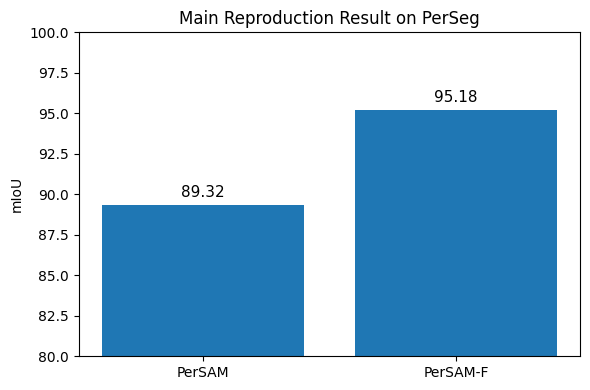

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("/content/drive/MyDrive/cs4782_persam_project/final_figures")
fig_dir.mkdir(parents=True, exist_ok=True)

methods = ["PerSAM", "PerSAM-F"]
miou = [89.32, 95.18]

plt.figure(figsize=(6, 4))
bars = plt.bar(methods, miou)
plt.ylabel("mIoU")
plt.title("Main Reproduction Result on PerSeg")
plt.ylim(80, 100)

for i, v in enumerate(miou):
    plt.text(i, v + 0.5, f"{v:.2f}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig(fig_dir / "main_miou_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

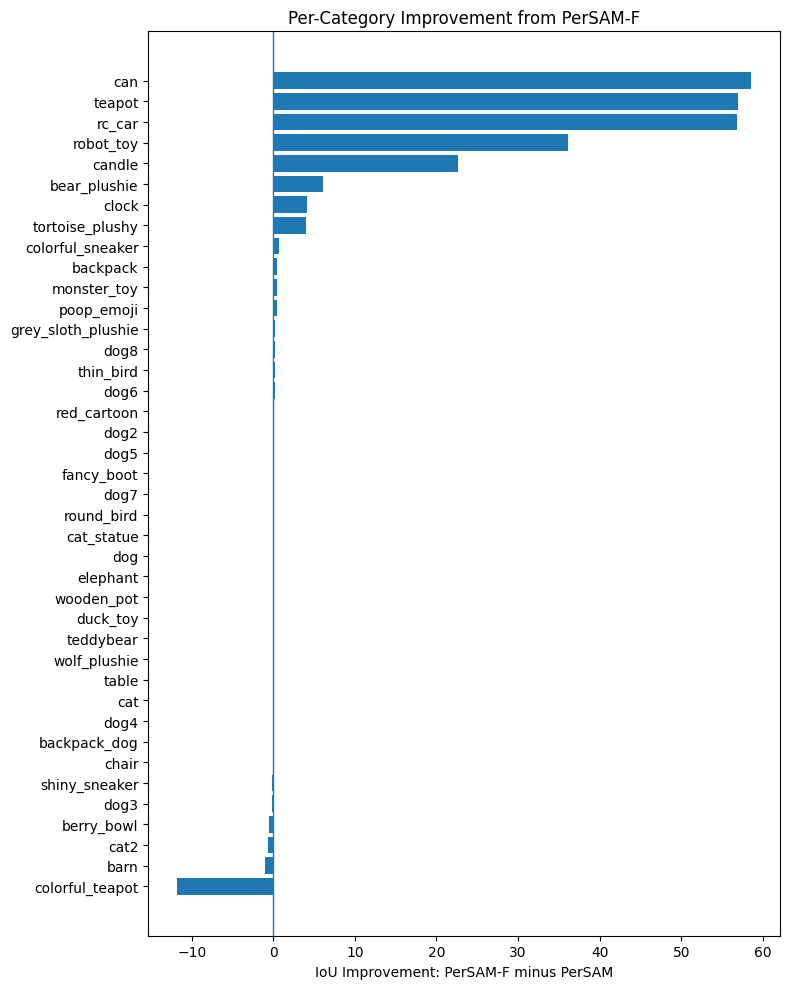

,Category,PerSAM_IoU,PerSAMF_IoU,Delta
5,can,38.91,97.49,58.58
34,teapot,40.02,96.93,56.91
28,rc_car,39.30,96.12,56.82
30,robot_toy,60.55,96.66,36.11
6,candle,74.16,96.76,22.60
3,bear_plushie,89.28,95.32,6.04
11,clock,90.70,94.79,4.09
37,tortoise_plushy,93.06,97.09,4.03
12,colorful_sneaker,94.48,95.13,0.65
0,backpack,96.17,96.66,0.49


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("/content/drive/MyDrive/cs4782_persam_project/final_figures")
fig_dir.mkdir(parents=True, exist_ok=True)

data = [
    ("backpack", 96.17, 96.66),
    ("backpack_dog", 95.85, 95.76),
    ("barn", 96.19, 95.17),
    ("bear_plushie", 89.28, 95.32),
    ("berry_bowl", 91.81, 91.27),
    ("can", 38.91, 97.49),
    ("candle", 74.16, 96.76),
    ("cat", 95.54, 95.51),
    ("cat2", 94.72, 94.05),
    ("cat_statue", 95.42, 95.46),
    ("chair", 92.23, 92.14),
    ("clock", 90.70, 94.79),
    ("colorful_sneaker", 94.48, 95.13),
    ("colorful_teapot", 96.27, 84.48),
    ("dog", 96.79, 96.81),
    ("dog2", 95.66, 95.79),
    ("dog3", 88.85, 88.67),
    ("dog4", 95.22, 95.18),
    ("dog5", 97.10, 97.22),
    ("dog6", 94.66, 94.85),
    ("dog7", 93.69, 93.77),
    ("dog8", 95.34, 95.61),
    ("duck_toy", 97.31, 97.31),
    ("elephant", 96.05, 96.07),
    ("fancy_boot", 95.87, 95.96),
    ("grey_sloth_plushie", 96.37, 96.64),
    ("monster_toy", 93.75, 94.21),
    ("poop_emoji", 96.01, 96.43),
    ("rc_car", 39.30, 96.12),
    ("red_cartoon", 96.96, 97.11),
    ("robot_toy", 60.55, 96.66),
    ("round_bird", 96.79, 96.85),
    ("shiny_sneaker", 97.00, 96.87),
    ("table", 94.68, 94.66),
    ("teapot", 40.02, 96.93),
    ("teddybear", 94.63, 94.61),
    ("thin_bird", 93.72, 93.96),
    ("tortoise_plushy", 93.06, 97.09),
    ("wolf_plushie", 94.34, 94.32),
    ("wooden_pot", 97.42, 97.43),
]

df = pd.DataFrame(data, columns=["Category", "PerSAM_IoU", "PerSAMF_IoU"])
df["Delta"] = df["PerSAMF_IoU"] - df["PerSAM_IoU"]
df = df.sort_values("Delta", ascending=True)

df.to_csv("/content/drive/MyDrive/cs4782_persam_project/final_results/per_category_iou_comparison.csv", index=False)

plt.figure(figsize=(8, 10))
plt.barh(df["Category"], df["Delta"])
plt.xlabel("IoU Improvement: PerSAM-F minus PerSAM")
plt.title("Per-Category Improvement from PerSAM-F")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.savefig(fig_dir / "per_category_improvement.png", dpi=300, bbox_inches="tight")
plt.show()

df.sort_values("Delta", ascending=False).head(10)

In [ ]:
from pathlib import Path
import shutil

project_root = Path("/content/drive/MyDrive/cs4782_persam_project")
repo_root = project_root / "Personalize-SAM"

selected_categories = [
    "can",
    "rc_car",
    "teapot",
    "robot_toy",
    "colorful_teapot",
    "dog",
    "cat",
    "bear_plushie",
]

dst = project_root / "final_figures" / "selected_qualitative_examples"
dst.mkdir(parents=True, exist_ok=True)

for cat in selected_categories:
    for method_name, outdir in [
        ("persam", "persam_repro_vith"),
        ("persam_f", "persam_f_repro_vith"),
    ]:
        src_dir = repo_root / "outputs" / outdir / cat
        if not src_dir.exists():
            print("Missing:", src_dir)
            continue

        # Copy first few visualization images
        for p in sorted(src_dir.glob("vis_mask_*.jpg"))[:3]:
            shutil.copy(p, dst / f"{cat}_{method_name}_{p.name}")

print("Saved qualitative examples to:")
print(dst)

Saved qualitative examples to:
/content/drive/MyDrive/cs4782_persam_project/final_figures/selected_qualitative_examples


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

import shutil
from pathlib import Path

repo_root = Path("/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM")

src = repo_root / "data"
backup = repo_root / "data_original_backup"

if not backup.exists():
    shutil.copytree(src, backup)
    print("Created backup:", backup)
else:
    print("Backup already exists:", backup)

[Errno 2] No such file or directory: '/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM'
/content


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM/data'

In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

import shutil
from pathlib import Path

repo_root = Path("/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM")

src = repo_root / "data"
backup = repo_root / "data_original_backup"

if not backup.exists():
    shutil.copytree(src, backup)
    print("Created backup:", backup)
else:
    print("Backup already exists:", backup)

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Backup already exists: /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM/data_original_backup


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!mkdir -p /content/drive/MyDrive/cs4782_persam_project/my_code

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM


In [ ]:
%%writefile /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py
import argparse
import shutil
from pathlib import Path

import cv2
import numpy as np


def binarize(mask):
    return ((mask > 127).astype(np.uint8) * 255)


def erode_mask(mask, k=15, iterations=1):
    kernel = np.ones((k, k), np.uint8)
    return cv2.erode(mask, kernel, iterations=iterations)


def dilate_mask(mask, k=15, iterations=1):
    kernel = np.ones((k, k), np.uint8)
    return cv2.dilate(mask, kernel, iterations=iterations)


def shift_mask(mask, dx=20, dy=20):
    h, w = mask.shape[:2]
    matrix = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(mask, matrix, (w, h), borderValue=0)


def noisy_mask(mask, p=0.02, seed=0):
    rng = np.random.default_rng(seed)
    noisy = mask.copy()
    flip = rng.random(mask.shape[:2]) < p
    noisy[flip] = 255 - noisy[flip]
    return noisy


def perturb(mask, mode):
    mask = binarize(mask)

    if mode == "original":
        return mask
    if mode == "erode":
        return erode_mask(mask, k=15, iterations=1)
    if mode == "dilate":
        return dilate_mask(mask, k=15, iterations=1)
    if mode == "shift":
        return shift_mask(mask, dx=20, dy=20)
    if mode == "noise":
        return noisy_mask(mask, p=0.02, seed=0)

    raise ValueError(f"Unknown perturbation mode: {mode}")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--src_data", required=True)
    parser.add_argument("--dst_data", required=True)
    parser.add_argument(
        "--mode",
        required=True,
        choices=["original", "erode", "dilate", "shift", "noise"],
    )
    parser.add_argument("--ref_idx", default="00")
    args = parser.parse_args()

    src_data = Path(args.src_data)
    dst_data = Path(args.dst_data)

    if dst_data.exists():
        shutil.rmtree(dst_data)

    shutil.copytree(src_data, dst_data)

    ann_root = dst_data / "Annotations"
    ref_name = f"{args.ref_idx}.png"

    ref_masks = sorted(ann_root.glob(f"*/{ref_name}"))
    print(f"Found {len(ref_masks)} reference masks.")

    for i, mask_path in enumerate(ref_masks):
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"Warning: could not read {mask_path}")
            continue

        out = perturb(mask, args.mode)
        cv2.imwrite(str(mask_path), out)

    print(f"Saved perturbed dataset to: {dst_data}")
    print(f"Perturbation mode: {args.mode}")


if __name__ == "__main__":
    main()

Writing /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_erode \
  --mode erode

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_dilate \
  --mode dilate

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_shift \
  --mode shift

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_noise \
  --mode noise

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Found 3 reference masks.
Saved perturbed dataset to: data_ref_erode
Perturbation mode: erode
Found 3 reference masks.
Saved perturbed dataset to: data_ref_dilate
Perturbation mode: dilate
Found 3 reference masks.
Saved perturbed dataset to: data_ref_shift
Perturbation mode: shift
Found 3 reference masks.
Saved perturbed dataset to: data_ref_noise
Perturbation mode: noise


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

print("Example annotation files:")
!find data_original_backup/Annotations -maxdepth 2 -type f | head -80

print("\nFiles matching 00.png:")
!find data_original_backup/Annotations -maxdepth 2 -type f -name "00.png" | wc -l

print("\nFiles matching 00.*:")
!find data_original_backup/Annotations -maxdepth 2 -type f -name "00.*" | wc -l

print("\nFiles matching 0.*:")
!find data_original_backup/Annotations -maxdepth 2 -type f -name "0.*" | wc -l

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Example annotation files:
data_original_backup/Annotations/fancy_boot/00.png
data_original_backup/Annotations/fancy_boot/01.png
data_original_backup/Annotations/fancy_boot/02.png
data_original_backup/Annotations/fancy_boot/04.png
data_original_backup/Annotations/fancy_boot/05.png
data_original_backup/Annotations/fancy_boot/03.png
data_original_backup/Annotations/shiny_sneaker/03.png
data_original_backup/Annotations/shiny_sneaker/04.png
data_original_backup/Annotations/shiny_sneaker/05.png
data_original_backup/Annotations/shiny_sneaker/02.png
data_original_backup/Annotations/shiny_sneaker/01.png
data_original_backup/Annotations/shiny_sneaker/00.png
data_original_backup/Annotations/dog2/01.png
data_original_backup/Annotations/dog2/03.png
data_original_backup/Annotations/dog2/02.png
data_original_backup/Annotations/dog2/00.png
data_original_backup/Annotations/dog2/04.png
data_original_backup/Annotations/dog2/05.png

Files matchi

In [ ]:
from pathlib import Path

ann_root = Path("/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM/data_original_backup/Annotations")

category_dirs = sorted([p for p in ann_root.iterdir() if p.is_dir()])
print("Number of categories:", len(category_dirs))

count_00 = 0
missing_00 = []

for d in category_dirs:
    p = d / "00.png"
    if p.exists():
        count_00 += 1
    else:
        missing_00.append(d.name)

print("Number of categories with 00.png:", count_00)
print("Missing 00.png:", missing_00[:20])
print("Number missing:", len(missing_00))

print("\nFirst few files per first 10 categories:")
for d in category_dirs[:10]:
    files = sorted([p.name for p in d.iterdir() if p.is_file()])
    print(d.name, files[:8])

Number of categories: 3
Number of categories with 00.png: 3
Missing 00.png: []
Number missing: 0

First few files per first 10 categories:
dog2 ['00.png', '01.png', '02.png', '03.png', '04.png', '05.png']
fancy_boot ['00.png', '01.png', '02.png', '03.png', '04.png', '05.png']
shiny_sneaker ['00.png', '01.png', '02.png', '03.png', '04.png', '05.png']


In [ ]:
%%bash
cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

for d in data_original_backup/Annotations/*; do
    echo "==== $(basename "$d") ===="
    ls "$d" | head -5
done

==== dog2 ====
00.png
01.png
02.png
03.png
04.png
==== fancy_boot ====
00.png
01.png
02.png
03.png
04.png
==== shiny_sneaker ====
00.png
01.png
02.png
03.png
04.png


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

# Remove incomplete backup and previous perturbed datasets
!rm -rf data_original_backup
!rm -rf data_ref_erode data_ref_dilate data_ref_shift data_ref_noise
!rm -rf tmp_perseg_unzip

# Unzip original PerSeg.zip into a temporary folder
!mkdir -p tmp_perseg_unzip
!unzip -q ../PerSeg.zip -d tmp_perseg_unzip

# The zip contains a folder named "data 3"; rename it to data_original_backup
!mv "tmp_perseg_unzip/data 3" data_original_backup

# Clean Mac metadata and temp folder
!rm -rf tmp_perseg_unzip
!rm -rf __MACOSX

# Check backup
!ls data_original_backup

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Annotations  Images


In [ ]:
from pathlib import Path

ann_root = Path("/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM/data_original_backup/Annotations")
img_root = Path("/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM/data_original_backup/Images")

ann_categories = sorted([p.name for p in ann_root.iterdir() if p.is_dir()])
img_categories = sorted([p.name for p in img_root.iterdir() if p.is_dir()])

print("Annotation categories:", len(ann_categories))
print("Image categories:", len(img_categories))

print("First 10 annotation categories:", ann_categories[:10])
print("First 10 image categories:", img_categories[:10])

count_00 = 0
missing_00 = []

for cat in ann_categories:
    p = ann_root / cat / "00.png"
    if p.exists():
        count_00 += 1
    else:
        missing_00.append(cat)

print("Categories with 00.png:", count_00)
print("Missing 00.png:", missing_00)

Annotation categories: 40
Image categories: 40
First 10 annotation categories: ['backpack', 'backpack_dog', 'barn', 'bear_plushie', 'berry_bowl', 'can', 'candle', 'cat', 'cat2', 'cat_statue']
First 10 image categories: ['backpack', 'backpack_dog', 'barn', 'bear_plushie', 'berry_bowl', 'can', 'candle', 'cat', 'cat2', 'cat_statue']
Categories with 00.png: 40
Missing 00.png: []


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!rm -rf data
!cp -r data_original_backup data

print("Current data check:")
!ls data
!find data/Annotations -mindepth 1 -maxdepth 1 -type d | wc -l

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Current data check:
Annotations  Images
40


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!rm -rf data_ref_erode data_ref_dilate data_ref_shift data_ref_noise

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_erode \
  --mode erode

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_dilate \
  --mode dilate

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_shift \
  --mode shift

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_noise \
  --mode noise

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Found 40 reference masks.
Saved perturbed dataset to: data_ref_erode
Perturbation mode: erode
Found 40 reference masks.
Saved perturbed dataset to: data_ref_dilate
Perturbation mode: dilate
Found 40 reference masks.
Saved perturbed dataset to: data_ref_shift
Perturbation mode: shift
Found 40 reference masks.
Saved perturbed dataset to: data_ref_noise
Perturbation mode: noise


In [ ]:
%%writefile /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py
import argparse
import shutil
from pathlib import Path

import cv2
import numpy as np


def to_binary_255(mask):
    """
    Convert annotation mask to binary {0, 255}.
    Important: PerSeg masks may use foreground value 38, not 255.
    Therefore we use mask > 0, not mask > 127.
    """
    return ((mask > 0).astype(np.uint8) * 255)


def perturb(mask, mode):
    mask = to_binary_255(mask)

    if mode == "original":
        return mask

    if mode == "erode":
        kernel = np.ones((7, 7), np.uint8)
        return cv2.erode(mask, kernel, iterations=1)

    if mode == "dilate":
        kernel = np.ones((7, 7), np.uint8)
        return cv2.dilate(mask, kernel, iterations=1)

    if mode == "shift":
        h, w = mask.shape[:2]
        matrix = np.float32([[1, 0, 15], [0, 1, 15]])
        return cv2.warpAffine(mask, matrix, (w, h), borderValue=0)

    if mode == "noise":
        rng = np.random.default_rng(0)
        noisy = mask.copy()

        # Randomly flip 1% pixels, while preserving most of the object.
        flip = rng.random(mask.shape[:2]) < 0.01
        noisy[flip] = 255 - noisy[flip]
        return noisy

    raise ValueError(f"Unknown mode: {mode}")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--src_data", required=True)
    parser.add_argument("--dst_data", required=True)
    parser.add_argument("--mode", required=True, choices=["original", "erode", "dilate", "shift", "noise"])
    parser.add_argument("--ref_idx", default="00")
    args = parser.parse_args()

    src_data = Path(args.src_data)
    dst_data = Path(args.dst_data)

    if dst_data.exists():
        shutil.rmtree(dst_data)

    shutil.copytree(src_data, dst_data)

    ann_root = dst_data / "Annotations"
    category_dirs = sorted([p for p in ann_root.iterdir() if p.is_dir()])

    changed = 0
    missing = []

    for category_dir in category_dirs:
        mask_path = category_dir / f"{args.ref_idx}.png"

        if not mask_path.exists():
            missing.append(category_dir.name)
            continue

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            missing.append(category_dir.name)
            continue

        out = perturb(mask, args.mode)
        cv2.imwrite(str(mask_path), out)
        changed += 1

    print(f"Categories found: {len(category_dirs)}")
    print(f"Reference masks changed: {changed}")
    print(f"Missing/unreadable: {missing}")
    print(f"Saved perturbed dataset to: {dst_data}")
    print(f"Perturbation mode: {args.mode}")


if __name__ == "__main__":
    main()

Overwriting /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!rm -rf data_ref_erode data_ref_dilate data_ref_shift data_ref_noise

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_erode \
  --mode erode

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_dilate \
  --mode dilate

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_shift \
  --mode shift

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_noise \
  --mode noise

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Categories found: 40
Reference masks changed: 40
Missing/unreadable: []
Saved perturbed dataset to: data_ref_erode
Perturbation mode: erode
Categories found: 40
Reference masks changed: 40
Missing/unreadable: []
Saved perturbed dataset to: data_ref_dilate
Perturbation mode: dilate
Categories found: 40
Reference masks changed: 40
Missing/unreadable: []
Saved perturbed dataset to: data_ref_shift
Perturbation mode: shift
Categories found: 40
Reference masks changed: 40
Missing/unreadable: []
Saved perturbed dataset to: data_ref_noise
Perturbation mode: noise


In [ ]:
import cv2
import numpy as np
from pathlib import Path

repo_root = Path("/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM")
category = "can"

paths = {
    "original": repo_root / "data_original_backup" / "Annotations" / category / "00.png",
    "erode": repo_root / "data_ref_erode" / "Annotations" / category / "00.png",
    "dilate": repo_root / "data_ref_dilate" / "Annotations" / category / "00.png",
    "shift": repo_root / "data_ref_shift" / "Annotations" / category / "00.png",
    "noise": repo_root / "data_ref_noise" / "Annotations" / category / "00.png",
}

for name, path in paths.items():
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    print("\n", name)
    print("min:", mask.min(), "max:", mask.max())
    print("unique values:", np.unique(mask)[:10])
    print("foreground pixels > 0:", np.sum(mask > 0))


 original
min: 0 max: 38
unique values: [ 0 38]
foreground pixels > 0: 381912

 erode
min: 0 max: 255
unique values: [  0 255]
foreground pixels > 0: 373962

 dilate
min: 0 max: 255
unique values: [  0 255]
foreground pixels > 0: 389934

 shift
min: 0 max: 255
unique values: [  0 255]
foreground pixels > 0: 381912

 noise
min: 0 max: 255
unique values: [  0 255]
foreground pixels > 0: 390758


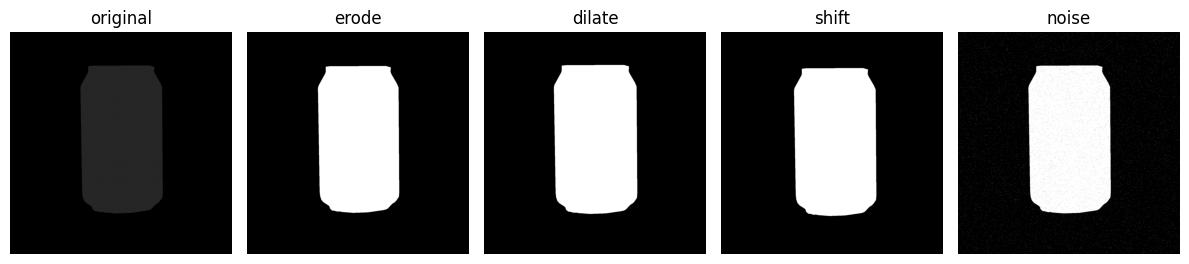

Saved to: /content/drive/MyDrive/cs4782_persam_project/final_figures/reference_mask_perturbations.png


In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

repo_root = Path("/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM")
category = "can"

paths = {
    "original": repo_root / "data_original_backup" / "Annotations" / category / "00.png",
    "erode": repo_root / "data_ref_erode" / "Annotations" / category / "00.png",
    "dilate": repo_root / "data_ref_dilate" / "Annotations" / category / "00.png",
    "shift": repo_root / "data_ref_shift" / "Annotations" / category / "00.png",
    "noise": repo_root / "data_ref_noise" / "Annotations" / category / "00.png",
}

plt.figure(figsize=(12, 3))

for i, (name, path) in enumerate(paths.items()):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    plt.subplot(1, 5, i + 1)
    plt.imshow(mask, cmap="gray", vmin=0, vmax=255)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()

out_path = "/content/drive/MyDrive/cs4782_persam_project/final_figures/reference_mask_perturbations.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", out_path)

In [ ]:
%%writefile /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py
import argparse
import shutil
from pathlib import Path

import cv2
import numpy as np


def to_binary_255(mask):
    """
    Convert annotation mask to binary {0, 255}.
    PerSeg masks may use foreground value 38, so use mask > 0.
    """
    return ((mask > 0).astype(np.uint8) * 255)


def perturb(mask, mode):
    mask = to_binary_255(mask)

    if mode == "original":
        return mask

    if mode == "erode":
        # Stronger erosion: visibly shrinks the reference mask
        kernel = np.ones((41, 41), np.uint8)
        return cv2.erode(mask, kernel, iterations=1)

    if mode == "dilate":
        # Stronger dilation: visibly enlarges the reference mask
        kernel = np.ones((41, 41), np.uint8)
        return cv2.dilate(mask, kernel, iterations=1)

    if mode == "shift":
        # Stronger shift: visibly moves the reference mask
        h, w = mask.shape[:2]
        matrix = np.float32([[1, 0, 120], [0, 1, 120]])
        return cv2.warpAffine(mask, matrix, (w, h), borderValue=0)

    if mode == "noise":
        # Add visible salt-and-pepper noise
        rng = np.random.default_rng(0)
        noisy = mask.copy()
        flip = rng.random(mask.shape[:2]) < 0.03
        noisy[flip] = 255 - noisy[flip]
        return noisy

    raise ValueError(f"Unknown mode: {mode}")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--src_data", required=True)
    parser.add_argument("--dst_data", required=True)
    parser.add_argument("--mode", required=True, choices=["original", "erode", "dilate", "shift", "noise"])
    parser.add_argument("--ref_idx", default="00")
    args = parser.parse_args()

    src_data = Path(args.src_data)
    dst_data = Path(args.dst_data)

    if dst_data.exists():
        shutil.rmtree(dst_data)

    shutil.copytree(src_data, dst_data)

    ann_root = dst_data / "Annotations"
    category_dirs = sorted([p for p in ann_root.iterdir() if p.is_dir()])

    changed = 0
    missing = []

    for category_dir in category_dirs:
        mask_path = category_dir / f"{args.ref_idx}.png"

        if not mask_path.exists():
            missing.append(category_dir.name)
            continue

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            missing.append(category_dir.name)
            continue

        out = perturb(mask, args.mode)
        cv2.imwrite(str(mask_path), out)
        changed += 1

    print(f"Categories found: {len(category_dirs)}")
    print(f"Reference masks changed: {changed}")
    print(f"Missing/unreadable: {missing}")
    print(f"Saved perturbed dataset to: {dst_data}")
    print(f"Perturbation mode: {args.mode}")


if __name__ == "__main__":
    main()

Overwriting /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py


In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

!rm -rf data_ref_erode data_ref_dilate data_ref_shift data_ref_noise

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_erode \
  --mode erode

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_dilate \
  --mode dilate

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_shift \
  --mode shift

!python /content/drive/MyDrive/cs4782_persam_project/my_code/perturb_reference_masks.py \
  --src_data data_original_backup \
  --dst_data data_ref_noise \
  --mode noise

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Categories found: 40
Reference masks changed: 40
Missing/unreadable: []
Saved perturbed dataset to: data_ref_erode
Perturbation mode: erode
Categories found: 40
Reference masks changed: 40
Missing/unreadable: []
Saved perturbed dataset to: data_ref_dilate
Perturbation mode: dilate
Categories found: 40
Reference masks changed: 40
Missing/unreadable: []
Saved perturbed dataset to: data_ref_shift
Perturbation mode: shift
Categories found: 40
Reference masks changed: 40
Missing/unreadable: []
Saved perturbed dataset to: data_ref_noise
Perturbation mode: noise


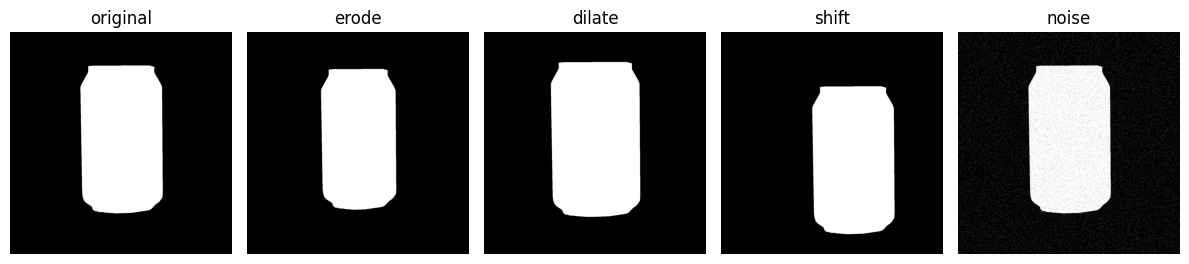

Saved to: /content/drive/MyDrive/cs4782_persam_project/final_figures/reference_mask_perturbations_stronger.png


In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

repo_root = Path("/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM")
category = "can"

paths = {
    "original": repo_root / "data_original_backup" / "Annotations" / category / "00.png",
    "erode": repo_root / "data_ref_erode" / "Annotations" / category / "00.png",
    "dilate": repo_root / "data_ref_dilate" / "Annotations" / category / "00.png",
    "shift": repo_root / "data_ref_shift" / "Annotations" / category / "00.png",
    "noise": repo_root / "data_ref_noise" / "Annotations" / category / "00.png",
}

plt.figure(figsize=(12, 3))

for i, (name, path) in enumerate(paths.items()):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    display_mask = ((mask > 0).astype(np.uint8) * 255)

    plt.subplot(1, 5, i + 1)
    plt.imshow(display_mask, cmap="gray", vmin=0, vmax=255)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()

out_path = "/content/drive/MyDrive/cs4782_persam_project/final_figures/reference_mask_perturbations_stronger.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", out_path)

In [ ]:
%cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM

# Use eroded reference masks
!rm -rf data
!cp -r data_ref_erode data

# Clean previous output if needed
!rm -rf outputs/persam_erode_ref_vith

# Run PerSAM
!python persam.py --outdir persam_erode_ref_vith

# Evaluate against ORIGINAL ground truth
!mkdir -p /content/drive/MyDrive/cs4782_persam_project/final_results

!python eval_miou.py \
  --pred_path persam_erode_ref_vith \
  --gt_path ./data_original_backup/Annotations \
  | tee /content/drive/MyDrive/cs4782_persam_project/final_results/persam_erode_ref_eval.txt

/content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
Args: Namespace(data='./data', outdir='persam_erode_ref_vith', ckpt='sam_vit_h_4b8939.pth', ref_idx='00', sam_type='vit_h')

------------> Segment dog8
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 8/8 [00:11<00:00,  1.50s/it]

------------> Segment cat
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:07<00:00,  1.57s/it]

------------> Segment dog6
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:07<00:00,  1.57s/it]

------------> Segment dog7
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:08<00:00,  1.66s/it]

------------> Segment wooden_pot
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 4/4 [00:14<00:00,  3.59s/it]

------------> Segment bear_plushie
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:11<00:00,  2.28s/it]

------------> S

In [ ]:
%%writefile /content/drive/MyDrive/cs4782_persam_project/my_code/run_persam_robustness.sh
#!/bin/bash

set -e

cd /content/drive/MyDrive/cs4782_persam_project/Personalize-SAM
mkdir -p /content/drive/MyDrive/cs4782_persam_project/final_results

for mode in erode dilate shift noise
do
    echo "=============================="
    echo "Running PerSAM with ${mode} reference mask"
    echo "=============================="

    rm -rf data
    cp -r data_ref_${mode} data

    rm -rf outputs/persam_${mode}_ref_vith

    python persam.py --outdir persam_${mode}_ref_vith

    python eval_miou.py \
      --pred_path persam_${mode}_ref_vith \
      --gt_path ./data_original_backup/Annotations \
      | tee /content/drive/MyDrive/cs4782_persam_project/final_results/persam_${mode}_ref_eval.txt
done

rm -rf data
cp -r data_original_backup data

echo "Finished all PerSAM robustness experiments."

Writing /content/drive/MyDrive/cs4782_persam_project/my_code/run_persam_robustness.sh


In [ ]:
!bash /content/drive/MyDrive/cs4782_persam_project/my_code/run_persam_robustness.sh

Running PerSAM with erode reference mask
Args: Namespace(data='./data', outdir='persam_erode_ref_vith', ckpt='sam_vit_h_4b8939.pth', ref_idx='00', sam_type='vit_h')

------------> Segment dog8
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 8/8 [00:11<00:00,  1.48s/it]

------------> Segment cat
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:08<00:00,  1.63s/it]

------------> Segment dog6
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:08<00:00,  1.72s/it]

------------> Segment dog7
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:08<00:00,  1.74s/it]

------------> Segment wooden_pot
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 4/4 [00:14<00:00,  3.61s/it]

------------> Segment bear_plushie
======> Load SAM
======> Obtain Location Prior
======> Start Testing
100% 5/5 [00:10<00:00,  2.16s/it]

------------> Segment can
======> L

In [ ]:
import re
from pathlib import Path
import pandas as pd

results_dir = Path("/content/drive/MyDrive/cs4782_persam_project/final_results")

def parse_eval_file(path):
    text = Path(path).read_text()
    miou_match = re.search(r"mIoU:\s*([0-9.]+)", text)
    macc_match = re.search(r"mAcc:\s*([0-9.]+)", text)
    return float(miou_match.group(1)), float(macc_match.group(1))

rows = [
    {"condition": "original", "mIoU": 89.32, "mAcc": 92.19},
]

for mode in ["erode", "dilate", "shift", "noise"]:
    path = results_dir / f"persam_{mode}_ref_eval.txt"
    if path.exists():
        miou, macc = parse_eval_file(path)
        rows.append({"condition": mode, "mIoU": miou, "mAcc": macc})

df = pd.DataFrame(rows)
df.to_csv(results_dir / "persam_robustness_summary.csv", index=False)
df

,condition,mIoU,mAcc
0,original,89.32,92.19
1,erode,88.45,92.18
2,dilate,87.33,90.23
3,shift,73.84,82.28
4,noise,89.32,92.19


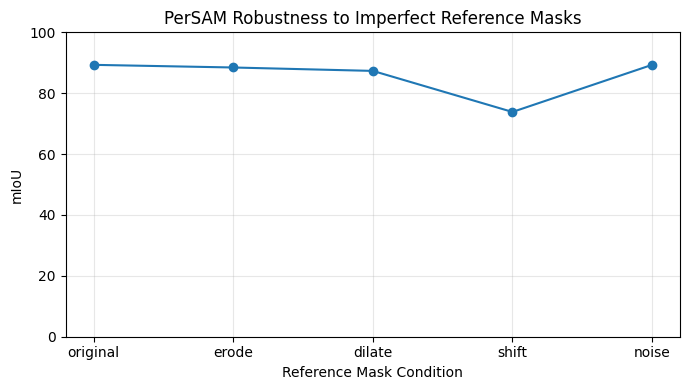

Saved to: /content/drive/MyDrive/cs4782_persam_project/final_figures/persam_reference_mask_robustness.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("/content/drive/MyDrive/cs4782_persam_project/final_results")
fig_dir = Path("/content/drive/MyDrive/cs4782_persam_project/final_figures")
fig_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(results_dir / "persam_robustness_summary.csv")

order = ["original", "erode", "dilate", "shift", "noise"]
df["condition"] = pd.Categorical(df["condition"], categories=order, ordered=True)
df = df.sort_values("condition")

plt.figure(figsize=(7, 4))
plt.plot(df["condition"], df["mIoU"], marker="o")
plt.ylabel("mIoU")
plt.xlabel("Reference Mask Condition")
plt.title("PerSAM Robustness to Imperfect Reference Masks")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = fig_dir / "persam_reference_mask_robustness.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", out_path)

In [7]:
from pathlib import Path
import shutil
import os

PROJECT_ROOT = Path("/content/drive/MyDrive/cs4782_persam_project")
PACKAGE_ROOT = PROJECT_ROOT / "github_upload_package"

# Remove old package if it exists
if PACKAGE_ROOT.exists():
    shutil.rmtree(PACKAGE_ROOT)

# Create required folders
folders = [
    "code",
    "data",
    "results",
    "poster",
    "report",
]

for folder in folders:
    (PACKAGE_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("Created clean GitHub package at:")
print(PACKAGE_ROOT)

Created clean GitHub package at:
/content/drive/MyDrive/cs4782_persam_project/github_upload_package


In [8]:
from pathlib import Path
import shutil

PROJECT_ROOT = Path("/content/drive/MyDrive/cs4782_persam_project")
PACKAGE_ROOT = PROJECT_ROOT / "github_upload_package"

# Copy your custom scripts
script_files = [
    PROJECT_ROOT / "my_code" / "perturb_reference_masks.py",
    PROJECT_ROOT / "my_code" / "run_persam_robustness.sh",
]

for src in script_files:
    if src.exists():
        shutil.copy(src, PACKAGE_ROOT / "code" / src.name)
        print("Copied:", src.name)
    else:
        print("Missing:", src)

Copied: perturb_reference_masks.py
Copied: run_persam_robustness.sh
